DATASET OVERVIEW
Dataset Shape: (4009, 12)

Column Names & Types:
brand           object
model           object
model_year       int64
milage          object
fuel_type       object
engine          object
transmission    object
ext_col         object
int_col         object
accident        object
clean_title     object
price           object
dtype: object

First few rows:
      brand                            model  model_year      milage  \
0      Ford  Utility Police Interceptor Base        2013  51,000 mi.   
1   Hyundai                     Palisade SEL        2021  34,742 mi.   
2     Lexus                    RX 350 RX 350        2022  22,372 mi.   
3  INFINITI                 Q50 Hybrid Sport        2015  88,900 mi.   
4      Audi        Q3 45 S line Premium Plus        2021   9,835 mi.   

       fuel_type                                             engine  \
0  E85 Flex Fuel  300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...   
1       Gasoline                               3.8L 

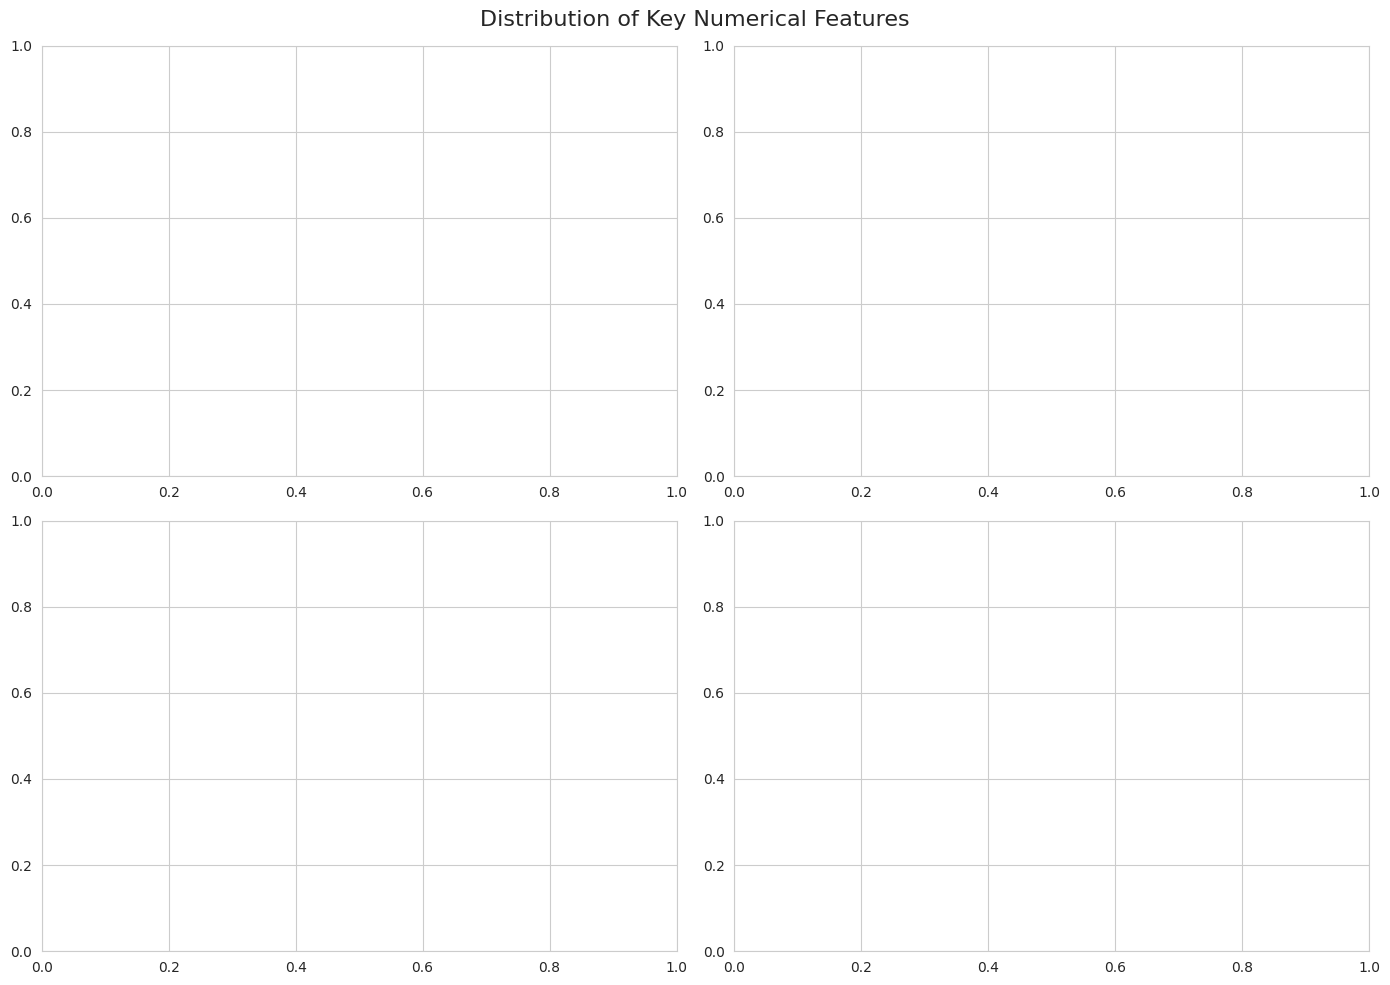


OUTLIER DETECTION

model_year:
  Outliers: 67 (1.67%)
  Bounds: [2000.00, 2032.00]

CATEGORICAL ANALYSIS

brand:
  Unique values: 57
  Top 5 values:
brand
Ford             386
BMW              375
Mercedes-Benz    315
Chevrolet        292
Porsche          201
Name: count, dtype: int64

model:
  Unique values: 1898
  Top 5 values:
model
M3 Base          30
F-150 XLT        24
Corvette Base    22
1500 Laramie     18
Camaro 2SS       17
Name: count, dtype: int64

milage:
  Unique values: 2818
  Top 5 values:
milage
110,000 mi.    16
45,000 mi.     15
120,000 mi.    13
55,000 mi.     13
54,000 mi.     12
Name: count, dtype: int64

fuel_type:
  Unique values: 7
  Top 5 values:
fuel_type
Gasoline         3309
Hybrid            194
E85 Flex Fuel     139
Diesel            116
–                  45
Name: count, dtype: int64

engine:
  Unique values: 1146
  Top 5 values:
engine
2.0L I4 16V GDI DOHC Turbo                               52
355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel             4

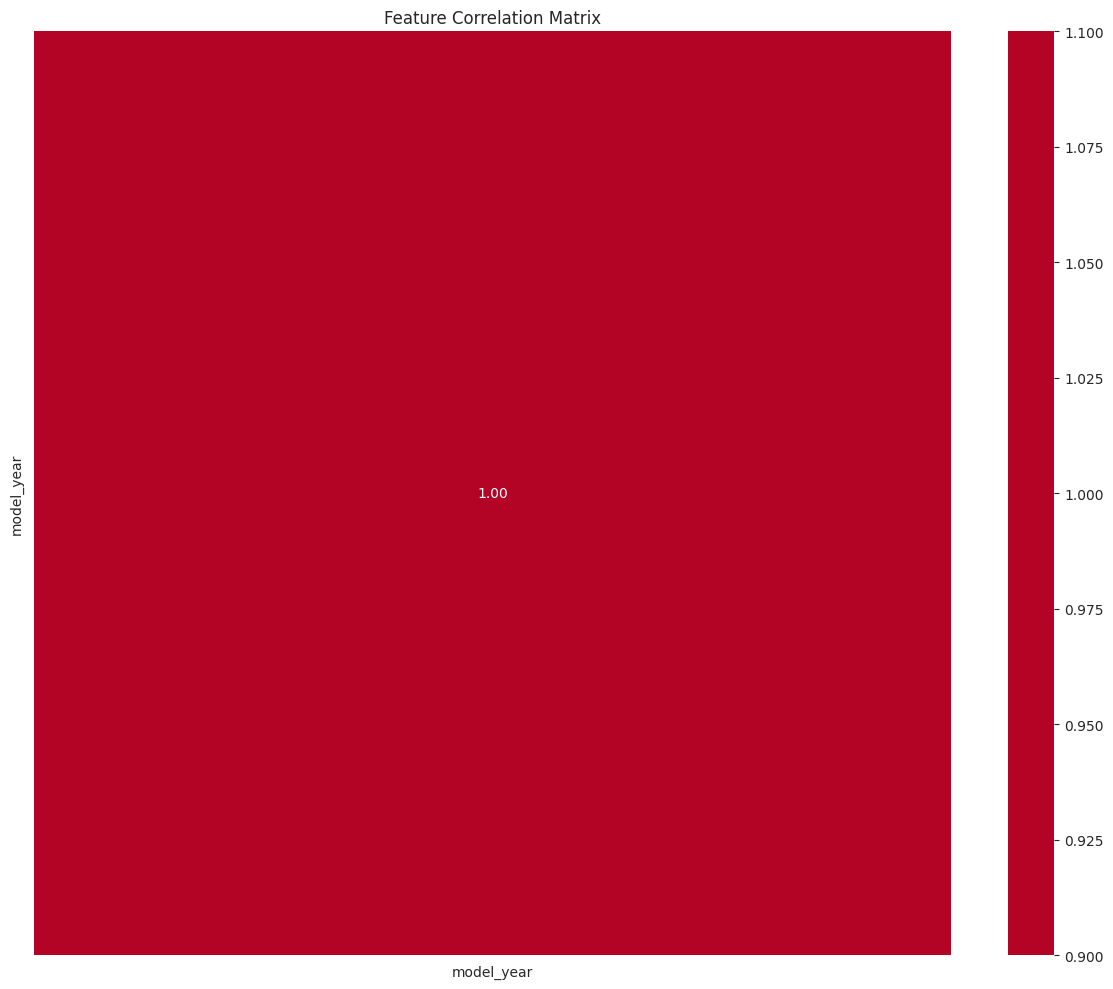


TARGET VARIABLE ANALYSIS (PRICE)

EDA COMPLETE - Ready for preprocessing


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ============ LOAD DATA ============
df = pd.read_csv('used_cars.csv')

# Display basic info
print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Names & Types:")
print(df.dtypes)
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData Info:")
print(df.info())

# ============ MISSING VALUES ANALYSIS ============
print("\n" + "=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)

missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing_count,
    'Percentage': missing_pct
}).sort_values('Percentage', ascending=False)

print(missing_df[missing_df['Percentage'] > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# ============ STATISTICAL SUMMARY ============
print("\n" + "=" * 80)
print("STATISTICAL SUMMARY")
print("=" * 80)
print(df.describe())

# ============ DUPLICATE ANALYSIS ============
print("\n" + "=" * 80)
print("DUPLICATE ANALYSIS")
print("=" * 80)
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate rows (all columns): {df.duplicated(keep=False).sum()}")

# ============ DISTRIBUTION ANALYSIS ============
print("\n" + "=" * 80)
print("DISTRIBUTION ANALYSIS")
print("=" * 80)

# For numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    print(f"\n{col}:")
    print(f"  Skewness: {df[col].skew():.3f}")
    print(f"  Kurtosis: {df[col].kurtosis():.3f}")

# Visualize distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Key Numerical Features', fontsize=16)

# Assuming 'Price' is your target variable
if 'Price' in df.columns:
    axes[0, 0].hist(df['Price'].dropna(), bins=50, edgecolor='black')
    axes[0, 0].set_title('Price Distribution')
    axes[0, 0].set_xlabel('Price (INR)')
    axes[0, 0].set_ylabel('Frequency')

# Add more visualizations for other columns
plt.tight_layout()
plt.show()

# ============ OUTLIER DETECTION ============
print("\n" + "=" * 80)
print("OUTLIER DETECTION")
print("=" * 80)

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Detect outliers in numerical columns
for col in numerical_cols:
    outliers, lower, upper = detect_outliers_iqr(df, col)
    print(f"\n{col}:")
    print(f"  Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
    print(f"  Bounds: [{lower:.2f}, {upper:.2f}]")

# ============ CATEGORICAL ANALYSIS ============
print("\n" + "=" * 80)
print("CATEGORICAL ANALYSIS")
print("=" * 80)

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  Unique values: {df[col].nunique()}")
    print(f"  Top 5 values:")
    print(df[col].value_counts().head())

# ============ CORRELATION ANALYSIS ============
print("\n" + "=" * 80)
print("CORRELATION ANALYSIS")
print("=" * 80)

# Correlation matrix
corr_matrix = df[numerical_cols].corr()
print("\nCorrelation with Price (Target Variable):")
if 'Price' in df.columns:
    print(corr_matrix['Price'].sort_values(ascending=False))

# Visualize correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# ============ TARGET VARIABLE ANALYSIS ============
print("\n" + "=" * 80)
print("TARGET VARIABLE ANALYSIS (PRICE)")
print("=" * 80)

if 'Price' in df.columns:
    price = df['Price'].dropna()
    print(f"Mean Price: ₹{price.mean():,.0f}")
    print(f"Median Price: ₹{price.median():,.0f}")
    print(f"Std Dev: ₹{price.std():,.0f}")
    print(f"Min Price: ₹{price.min():,.0f}")
    print(f"Max Price: ₹{price.max():,.0f}")
    print(f"Price Range: ₹{price.max() - price.min():,.0f}")

print("\n" + "=" * 80)
print("EDA COMPLETE - Ready for preprocessing")
print("=" * 80)
